In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv('breast-cancer.csv')
df.drop(columns=['id'], inplace=True)
df.reset_index(drop=True, inplace=True)

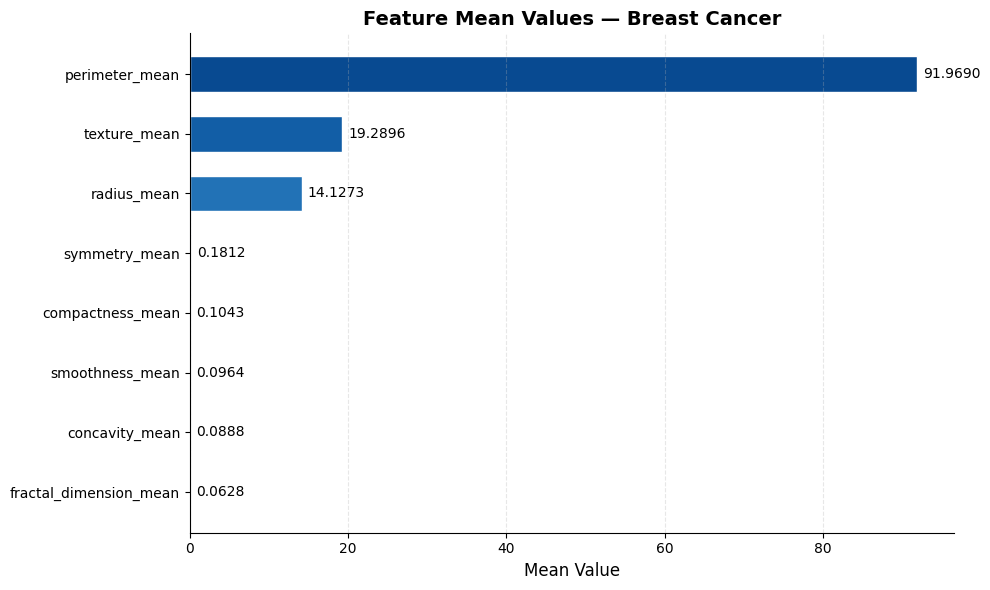

In [2]:
mean_features = ['radius_mean','texture_mean','perimeter_mean',
                 'smoothness_mean','compactness_mean','concavity_mean',
                 'symmetry_mean','fractal_dimension_mean']

means = df[mean_features].mean()
means_sorted = means.sort_values(ascending=True)   # ছোট নিচে, বড় উপরে
colors = plt.cm.Blues(np.linspace(0.35, 0.9, len(means_sorted)))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(means_sorted.index, means_sorted.values,
               color=colors, edgecolor='white', height=0.6)
ax.bar_label(bars, fmt='%.4f', fontsize=10, padding=4)

ax.set_title('Feature Mean Values — Breast Cancer', fontsize=14, fontweight='bold')
ax.set_xlabel('Mean Value', fontsize=12)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

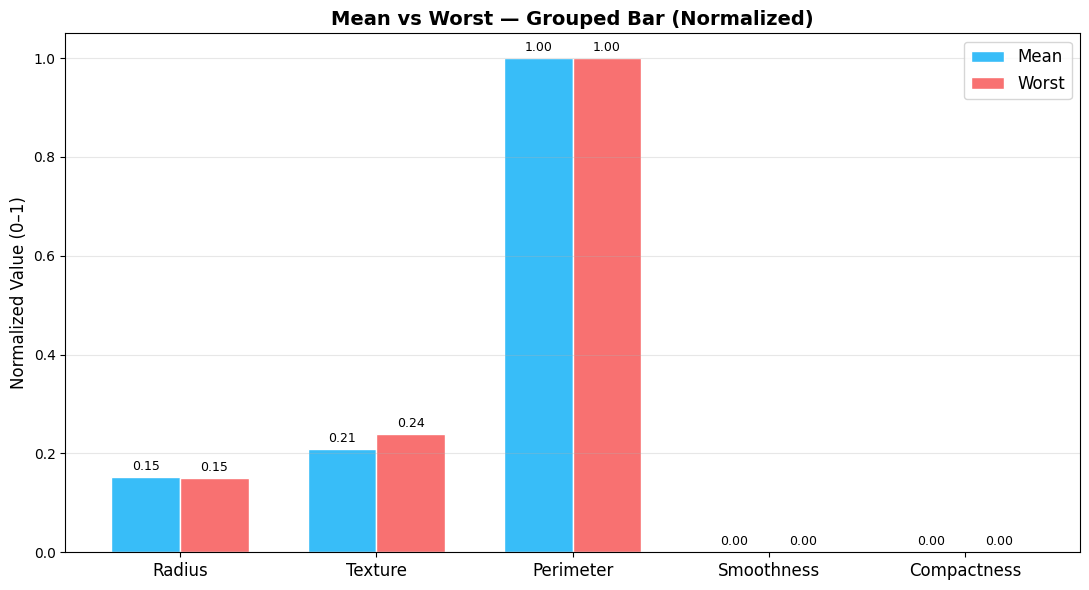

In [3]:
features_base = ['radius', 'texture', 'perimeter', 'smoothness', 'compactness']
mean_vals  = [df[f'{f}_mean'].mean()  for f in features_base]
worst_vals = [df[f'{f}_worst'].mean() for f in features_base]

# normalize 0-1 — scale আলাদা হওয়ায় directly compare হয় না
def norm(arr):
    arr = np.array(arr)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-9)

mean_n  = norm(mean_vals)
worst_n = norm(worst_vals)

x = np.arange(len(features_base))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - width/2, mean_n,  width, label='Mean',  color='#38bdf8', edgecolor='white')
b2 = ax.bar(x + width/2, worst_n, width, label='Worst', color='#f87171', edgecolor='white')

ax.bar_label(b1, fmt='%.2f', fontsize=9, padding=3)
ax.bar_label(b2, fmt='%.2f', fontsize=9, padding=3)
ax.set_xticks(x)
ax.set_xticklabels([f.capitalize() for f in features_base], fontsize=12)
ax.set_title('Mean vs Worst — Grouped Bar (Normalized)', fontsize=14, fontweight='bold')
ax.set_ylabel('Normalized Value (0–1)', fontsize=12)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

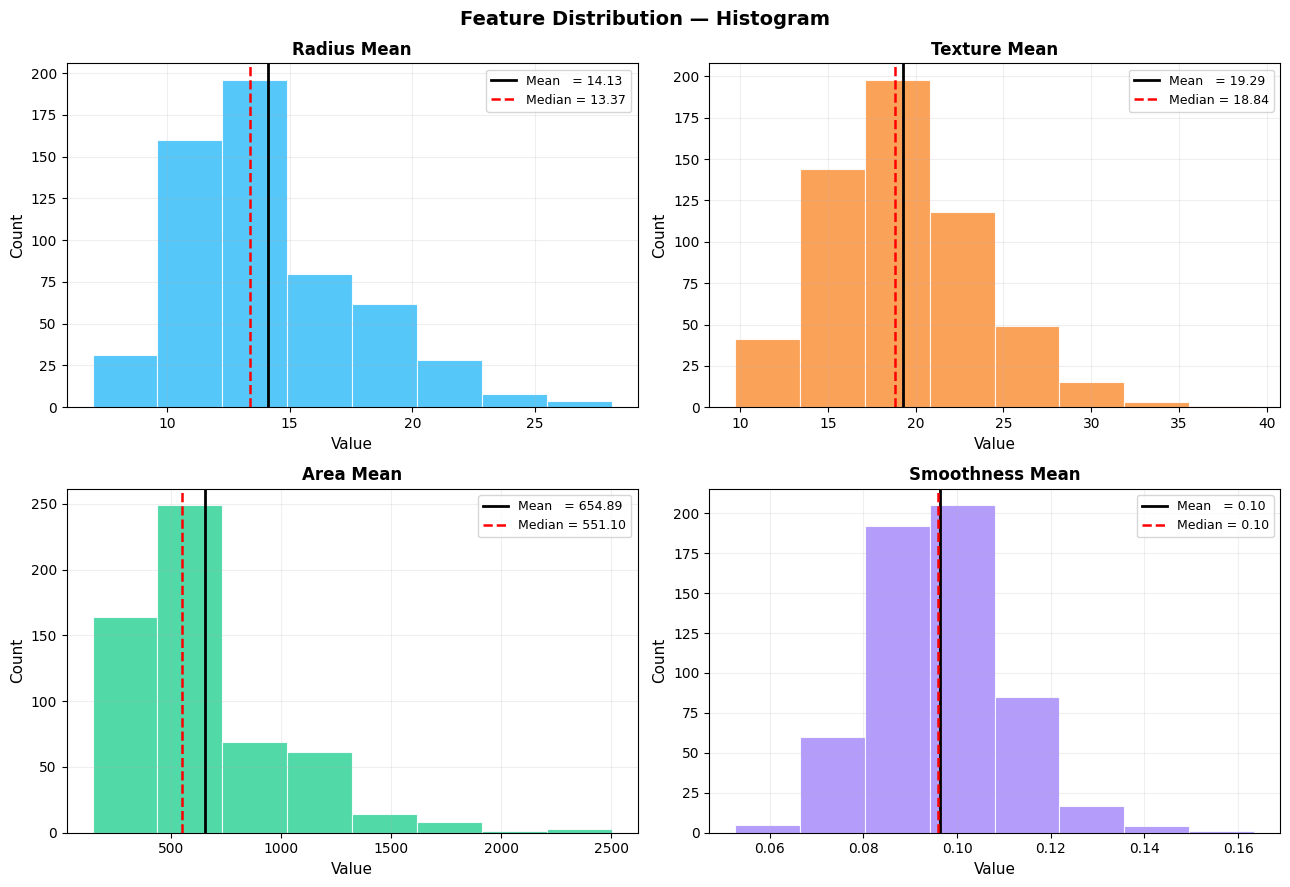

In [4]:
hist_features = ['radius_mean','texture_mean','area_mean','smoothness_mean']
colors_h = ['#38bdf8', '#fb923c', '#34d399', '#a78bfa']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, col, color in zip(axes.flat, hist_features, colors_h):
    vals = df[col]
    ax.hist(vals, bins=8, color=color, alpha=0.85,
            edgecolor='white', linewidth=0.8)

    ax.axvline(vals.mean(),   color='black', lw=2,   ls='-',
               label=f'Mean   = {vals.mean():.2f}')
    ax.axvline(vals.median(), color='red',   lw=1.8, ls='--',
               label=f'Median = {vals.median():.2f}')

    ax.set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Value', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

fig.suptitle('Feature Distribution — Histogram', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

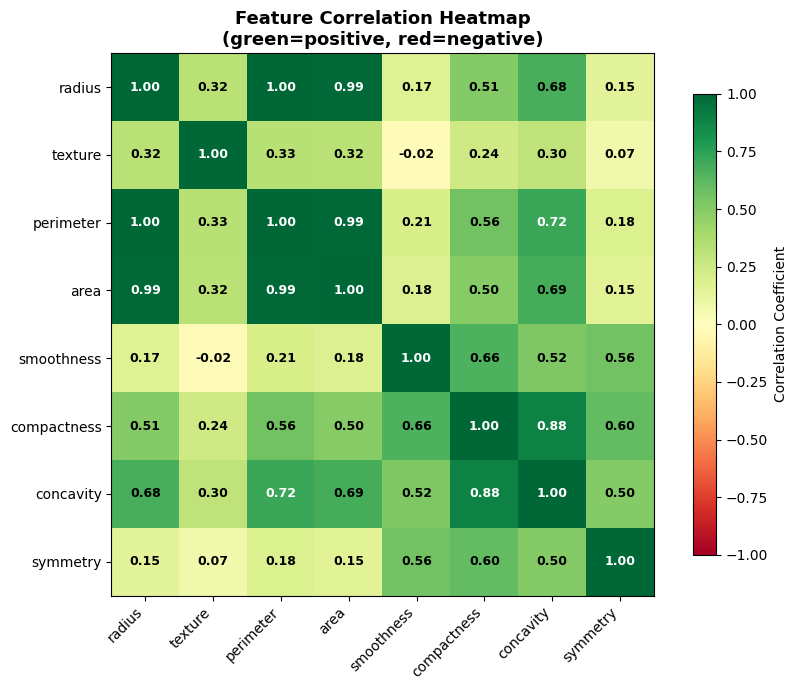

In [5]:
heat_cols = ['radius_mean','texture_mean','perimeter_mean','area_mean',
             'smoothness_mean','compactness_mean','concavity_mean','symmetry_mean']
corr = df[heat_cols].corr()
short = [c.replace('_mean','') for c in heat_cols]

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Correlation Coefficient', shrink=0.85)

for i in range(len(short)):
    for j in range(len(short)):
        val = corr.values[i, j]
        txt_color = 'white' if abs(val) > 0.7 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, fontweight='bold', color=txt_color)

ax.set_xticks(range(len(short))); ax.set_xticklabels(short, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(short))); ax.set_yticklabels(short, fontsize=10)
ax.set_title('Feature Correlation Heatmap\n(green=positive, red=negative)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

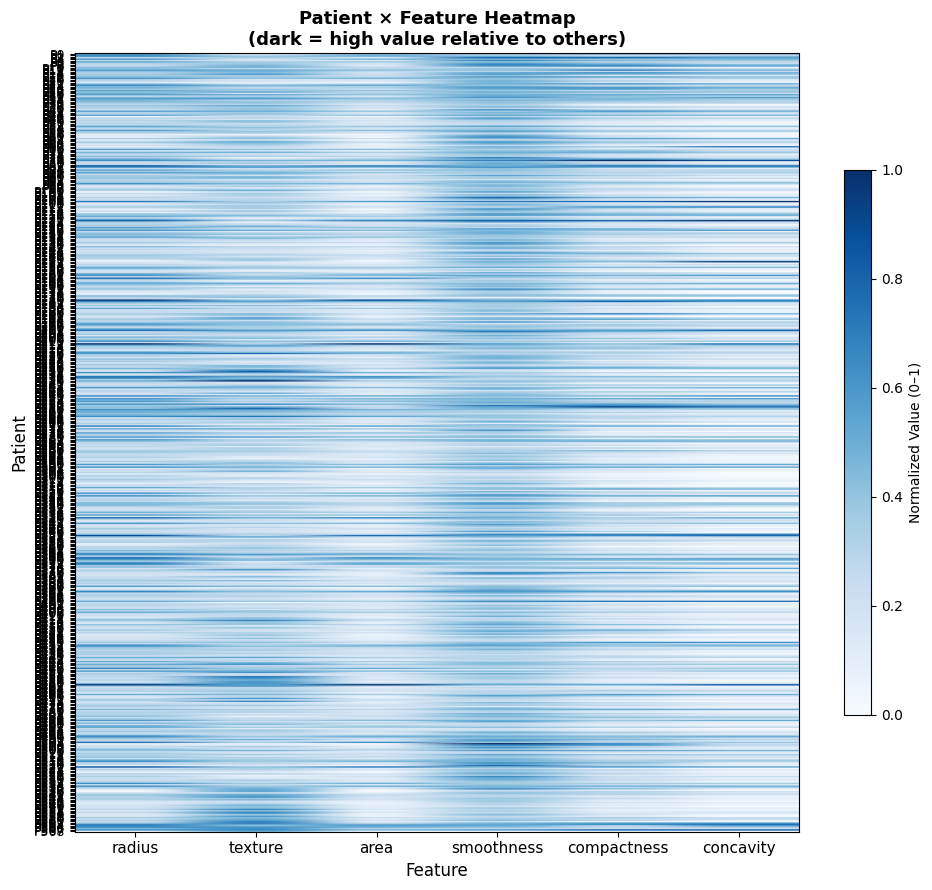

In [6]:
feat_cols = ['radius_mean','texture_mean','area_mean',
             'smoothness_mean','compactness_mean','concavity_mean']

# প্রতিটা column আলাদাভাবে 0-1 normalize করো
data_norm = df[feat_cols].copy()
for c in feat_cols:
    mn, mx = data_norm[c].min(), data_norm[c].max()
    data_norm[c] = (data_norm[c] - mn) / (mx - mn)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(data_norm.values, cmap='Blues', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Normalized Value (0–1)', shrink=0.7)

short_f = [c.replace('_mean','') for c in feat_cols]
ax.set_xticks(range(len(short_f))); ax.set_xticklabels(short_f, fontsize=11)
ax.set_yticks(range(len(df)));      ax.set_yticklabels([f'P{i}' for i in range(len(df))], fontsize=9)
ax.set_title('Patient × Feature Heatmap\n(dark = high value relative to others)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature', fontsize=12)
ax.set_ylabel('Patient', fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'predicted'],
      dtype='object')